Ok now we are having a comprehensive understanding at all aspects I want to have the following now



Headline results:

Headline results is where we discuss on how the "training" will be done, how the training performs with no pre alignment, pre alignment with public probe (on different sizes) with different models (MLP, CNN etc pick a few that we can train on meaningfully)
a


The Resnet and ViT results on fine tuning



Bert and maybe with a GPT type results on fine tuning



I want to start over with a new colab notebook, design this new notebook so that it will have a place to write the results to, printing tables and drawing figures in meaningful places, can start over based on the previous runs (ie when the notebook is down it should be able to continue from recovering on previous states) and figures numbers in folders in a well structured way so that later on I can download the folder and continue working on like redar the figures and so on.



I have H100 A100 etc too and I can run 10 hours with them but if you think those will be unnecessary we can go on with L4 or T4 too make the time cost efficiceny calculation.



Desgin the papers experimental grid and return the colab notebook. We can do the experiments with multiple seeds from now on.

In [1]:
# =====================================================================
# HE-IFD experimental grid
# =====================================================================
# Single file split into cells by `# %% [markdown]` and `# %%` markers.
# Paste each cell into Colab in order. Resumable: re-running any cell
# skips work already done. State persists across Colab session restarts
# under /content/he_ifd_output/.
#
# Hardware: T4 is sufficient. A100 saves ~30 min on feature extraction.
# Total runtime: ~3 hours on T4, ~2 hours on A100.
# =====================================================================



# # HE-IFD: Final Experimental Grid
#
# This notebook produces the headline results, ablations, and figures
# for the HE-IFD paper. It is organised into sections:
#
# - **Section 0:** Setup, paths, helpers, feature extraction (cached)
# - **Section A:** From-scratch MNIST MLP (probe-size sweep, heterogeneity sweep)
# - **Section B:** Pretrained vision backbones (ResNet-18, ViT-B/32 on CIFAR-10)
# - **Section C:** Pretrained text backbones (DistilBERT, GPT-2 on AG News)
# - **Section D:** DP privacy/utility frontier (averaging-variant mechanism)
# - **Section E:** Final tables and figures aggregated across all sections
#
# Each experiment is described by a deterministic task descriptor and its
# result is persisted to disk. Re-running a section skips completed tasks.



# ## Section 0.1: Output directories and global config


import os
import json
import time
import pickle
import hashlib
from pathlib import Path

ROOT = Path("/content/he_ifd_output")
DIRS = {
    "results":  ROOT / "results",
    "features": ROOT / "features",
    "figures":  ROOT / "figures",
    "tables":   ROOT / "tables",
    "logs":     ROOT / "logs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

RESULTS_FILE = DIRS["results"] / "results.pkl"

def load_results():
    if RESULTS_FILE.exists():
        with open(RESULTS_FILE, "rb") as f:
            return pickle.load(f)
    return {}

def save_results(results):
    with open(RESULTS_FILE, "wb") as f:
        pickle.dump(results, f)

def task_key(descriptor):
    """Deterministic hash for a task descriptor dict."""
    canon = json.dumps(descriptor, sort_keys=True, default=str)
    return hashlib.sha256(canon.encode()).hexdigest()[:16]

def task_done(results, descriptor):
    return task_key(descriptor) in results

def record_task(results, descriptor, result):
    results[task_key(descriptor)] = {"descriptor": descriptor, "result": result}
    save_results(results)

print(f"Output root: {ROOT}")
print(f"Results file: {RESULTS_FILE}")
results = load_results()
print(f"Existing results: {len(results)} tasks already completed")




Output root: /content/he_ifd_output
Results file: /content/he_ifd_output/results/results.pkl
Existing results: 0 tasks already completed


In [2]:

# ## Section 0.2: Imports and global hyperparameters


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Protocol hyperparameters (fixed across sections unless noted)
N_CLIENTS         = 16
SEEDS             = [42, 43, 44]                # 3-seed replications
ALPHAS            = [0.05, 0.1, 0.3, 1.0]
K_DISTILL_STEPS   = 300
TAU               = 4.0
STUDENT_LR        = 0.01
TEACHER_LR        = 0.05
TEACHER_MOMENTUM  = 0.9
TEACHER_EPOCHS    = 5
ORACLE_EPOCHS     = 10
WARMUP_EPOCHS     = 5
BS                = 64

# Pretrained-backbone-specific (head fine-tuning is faster, smaller LR)
TEACHER_EPOCHS_HEAD = 3
TEACHER_LR_HEAD     = 0.01
ORACLE_EPOCHS_HEAD  = 5
BS_HEAD             = 128

# DP
DP_DELTA          = 1e-5
CLIP_PERCENTILE   = 95




Device: cuda
GPU: Tesla T4


In [3]:

# ## Section 0.3: Core helpers (model, training, distillation, aggregation)

# %%
def get_params(model):
    return {k: v.detach().clone() for k, v in model.state_dict().items()}

def set_params(model, params):
    model.load_state_dict(params)

def params_diff(p1, p0):
    return {k: p1[k] - p0[k] for k in p1}

def zero_like(params):
    return {k: torch.zeros_like(v) for k, v in params.items()}

@torch.no_grad()
def accuracy_on(model, X, y, bs=512):
    model.eval()
    n = X.shape[0]
    correct = 0
    for i in range(0, n, bs):
        xb = X[i:i+bs].to(DEVICE) if X.device.type == "cpu" else X[i:i+bs]
        yb = y[i:i+bs].to(DEVICE) if y.device.type == "cpu" else y[i:i+bs]
        correct += (model(xb).argmax(1) == yb).sum().item()
    return correct / n


def dirichlet_partition(y_np, n_clients, alpha, seed, num_classes):
    rng = np.random.default_rng(seed)
    by_class = [np.where(y_np == c)[0] for c in range(num_classes)]
    client_idx = [[] for _ in range(n_clients)]
    for c in range(num_classes):
        idx = by_class[c].copy()
        rng.shuffle(idx)
        props = rng.dirichlet([alpha] * n_clients)
        splits = np.split(idx, (np.cumsum(props) * len(idx)).astype(int)[:-1])
        for i, s in enumerate(splits):
            client_idx[i].extend(s.tolist())
    return [np.array(c) for c in client_idx]


def train_supervised_model(make_model_fn, X, y, epochs, lr, momentum, bs, seed,
                            init_params=None, loss_fn=None):
    """Generic supervised SGD trainer. make_model_fn() returns a fresh model."""
    torch.manual_seed(seed)
    model = make_model_fn()
    if init_params is not None:
        model.load_state_dict(init_params)
    if loss_fn is None:
        loss_fn = F.cross_entropy
    X = X.to(DEVICE); y = y.to(DEVICE)
    n = X.shape[0]
    if n == 0:
        return model
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            opt.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()
            opt.step()
    return model


def local_distill_trajectory(teacher, init_params, make_model_fn, X,
                              K_steps, lr, momentum, tau, bs):
    student = make_model_fn()
    student.load_state_dict(init_params)
    teacher.eval()
    X = X.to(DEVICE)
    n = X.shape[0]
    if n == 0:
        return [zero_like(init_params) for _ in range(K_steps)]
    opt = torch.optim.SGD(student.parameters(), lr=lr, momentum=momentum)
    deltas = []
    for _ in range(K_steps):
        idx = torch.randint(0, n, (min(bs, n),), device=DEVICE)
        xb = X[idx]
        with torch.no_grad():
            t_logits = teacher(xb)
        prev = get_params(student)
        opt.zero_grad()
        s_logits = student(xb)
        loss = F.kl_div(F.log_softmax(s_logits / tau, dim=1),
                          F.softmax(t_logits / tau, dim=1),
                          reduction="batchmean") * (tau ** 2)
        loss.backward()
        opt.step()
        deltas.append(params_diff(get_params(student), prev))
    return deltas


def server_aggregate(init_params, all_deltas, weights):
    """Sample-weighted plaintext aggregation of per-step deltas."""
    K_local = len(all_deltas[0])
    theta = {k: v.detach().clone() for k, v in init_params.items()}
    for step in range(K_local):
        for i, w in enumerate(weights):
            d = all_deltas[i][step]
            for k in theta:
                theta[k] = theta[k] + w * d[k]
    return theta


def compute_feature_norms_percentile(X, p=CLIP_PERCENTILE, max_samples=5000):
    n = min(X.shape[0], max_samples)
    idx = np.random.default_rng(0).choice(X.shape[0], n, replace=False)
    return float(np.percentile(X[idx].norm(dim=1).numpy(), p))




In [4]:

# ## Section 0.4: Phase-0 alignment-probe builders
#
# Three variants used across the paper:
#
# - **Raw / no Phase 0:** start the encrypted distillation from a fresh init.
# - **Raw alignment (`raw_union_K`):** every client contributes K samples per
#   class as the alignment probe, with no DP. This is the no-privacy ceiling.
# - **DP-averaged alignment (`dp_avg_eps_K`):** every client averages K samples
#   per class, adds Gaussian noise calibrated to ε, server averages contributions
#   per class. This is the privacy-preserving mechanism.
# - **Labelled-probe baseline:** standard plaintext SGD on a held-out labelled
#   probe of size P. This is the cheating-with-public-data baseline.

# %%
def build_probe_raw_union(client_X_list, client_y_list, K_per_class,
                            num_classes, seed=0):
    """Union of clipped raw samples per client per class. No DP."""
    rng = np.random.default_rng(seed)
    probe_X_list, probe_y_list = [], []
    for i in range(len(client_X_list)):
        X_i = client_X_list[i].cpu()
        y_i = client_y_list[i].cpu().numpy()
        for c in range(num_classes):
            mask = (y_i == c)
            n_avail = int(mask.sum())
            if n_avail == 0:
                continue
            X_c = X_i[mask]
            n_take = min(K_per_class, n_avail)
            idx = rng.choice(n_avail, n_take, replace=False)
            samples = X_c[idx]
            probe_X_list.append(samples)
            probe_y_list.append(torch.full((n_take,), c, dtype=torch.long))
    probe_X = torch.cat(probe_X_list, dim=0)
    probe_y = torch.cat(probe_y_list, dim=0)
    return probe_X, probe_y, {"probe_size": int(probe_X.shape[0]), "sigma": 0.0}


def build_probe_dp_averaged(client_X_list, client_y_list, K_per_class,
                              num_classes, clip, eps_per_client,
                              delta=DP_DELTA, seed=0):
    """
    Per client per class:
      - L2-clip K_per_class samples to `clip`
      - average them -> one contribution
      - add Gaussian noise sigma = (clip/K) * sqrt(2 ln(1.25/delta)) / eps
        (sensitivity of mean of K bounded vectors is clip/K under
        replace-one neighboring datasets, with parallel composition over classes)
    Server: average contributions across clients per class.
    Returns probe_X of shape (num_classes_with_contributors, feature_dim).
    """
    rng = np.random.default_rng(seed)
    if eps_per_client == float("inf"):
        sigma = 0.0
    else:
        sensitivity = clip / K_per_class
        sigma = sensitivity * np.sqrt(2.0 * np.log(1.25 / delta)) / eps_per_client

    feature_dim = client_X_list[0].shape[1]
    accum = torch.zeros(num_classes, feature_dim)
    count = torch.zeros(num_classes)

    for i in range(len(client_X_list)):
        X_i = client_X_list[i].cpu()
        y_i = client_y_list[i].cpu().numpy()
        for c in range(num_classes):
            mask = (y_i == c)
            n_avail = int(mask.sum())
            if n_avail == 0:
                continue
            X_c = X_i[mask]
            n_take = min(K_per_class, n_avail)
            idx = rng.choice(n_avail, n_take, replace=False)
            samples = X_c[idx].clone()
            norms = samples.norm(dim=1, keepdim=True)
            scale = torch.minimum(torch.ones_like(norms),
                                    clip / norms.clamp_min(1e-6))
            samples = samples * scale
            contribution = samples.mean(dim=0)
            if sigma > 0:
                noise = torch.from_numpy(
                    rng.normal(0, sigma, contribution.shape).astype(np.float32))
                contribution = contribution + noise
            accum[c] += contribution
            count[c] += 1

    valid = count > 0
    probe_X = accum[valid] / count[valid].unsqueeze(1)
    probe_y = torch.arange(num_classes)[valid]
    return probe_X, probe_y, {"probe_size": int(valid.sum()), "sigma": float(sigma)}




In [5]:

# ## Section 0.5: One-shot federated distillation runner
#
# Single function that runs the full protocol given an initialization,
# returns the final-student accuracy. All methods plug in here by choosing
# the initialization (random/warmed) and reporting back.

# %%
def run_protocol_from_init(init_params, teachers, client_X_list, sample_sizes,
                             make_model_fn, X_test, y_test, K_steps,
                             student_lr, student_momentum, tau, bs):
    """The encrypted-protocol stage: K steps of local distillation per client,
    aggregated server-side. Always sample-weighted. Returns test accuracy."""
    sizes = torch.tensor(sample_sizes, dtype=torch.float32)
    weights = (sizes / sizes.sum()).tolist()
    all_deltas = []
    for i in range(len(teachers)):
        deltas = local_distill_trajectory(
            teachers[i], init_params, make_model_fn,
            client_X_list[i], K_steps, student_lr, student_momentum, tau, bs,
        )
        all_deltas.append(deltas)
    final_params = server_aggregate(init_params, all_deltas, weights)
    model = make_model_fn()
    model.load_state_dict(final_params)
    return accuracy_on(model, X_test, y_test), final_params


# =====================================================================


In [6]:

# # Section 0.6: Logging utilities

# %%
def log_status(section, msg):
    line = f"[{section}] {msg}"
    print(line)
    with open(DIRS["logs"] / f"{section}.log", "a") as f:
        f.write(line + "\n")


def summary_table(results, filter_section=None):
    """Flatten the results dict into a DataFrame for inspection."""
    rows = []
    for key, entry in results.items():
        d = entry["descriptor"]
        r = entry["result"]
        if filter_section and not d.get("section", "").startswith(filter_section):
            continue
        flat = {**d, **r}
        rows.append(flat)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


# =====================================================================


MNIST: train torch.Size([60000, 784]), test torch.Size([10000, 784])
[A] Total tasks: 216; already completed: 0
[A] seed=42 α=0.05 P=25 no_phase0: acc=0.3930 (36.2s)
[A] seed=42 α=0.05 P=25 warmup_only_labelled: acc=0.1531 (18.7s)
[A] seed=42 α=0.05 P=25 labelled_probe_warmup: acc=0.3341 (29.6s)
[A] seed=42 α=0.05 P=25 raw_union_K20: acc=0.8775 (29.7s)
[A] seed=42 α=0.05 P=25 dp_avg_eps2_K20: acc=0.4127 (29.7s)
[A] seed=42 α=0.05 P=25 dp_avg_eps8_K20: acc=0.4739 (30.2s)
[A] seed=42 α=0.05 P=100 no_phase0: acc=0.4127 (30.2s)
[A] seed=42 α=0.05 P=100 warmup_only_labelled: acc=0.4313 (18.3s)
[A] seed=42 α=0.05 P=100 labelled_probe_warmup: acc=0.6395 (30.8s)
[A] seed=42 α=0.05 P=100 raw_union_K20: acc=0.8854 (30.3s)
[A] seed=42 α=0.05 P=100 dp_avg_eps2_K20: acc=0.5378 (29.0s)
[A] seed=42 α=0.05 P=100 dp_avg_eps8_K20: acc=0.5215 (29.6s)
[A] seed=42 α=0.05 P=500 no_phase0: acc=0.4189 (29.4s)
[A] seed=42 α=0.05 P=500 warmup_only_labelled: acc=0.7987 (19.0s)
[A] seed=42 α=0.05 P=500 labelled_p

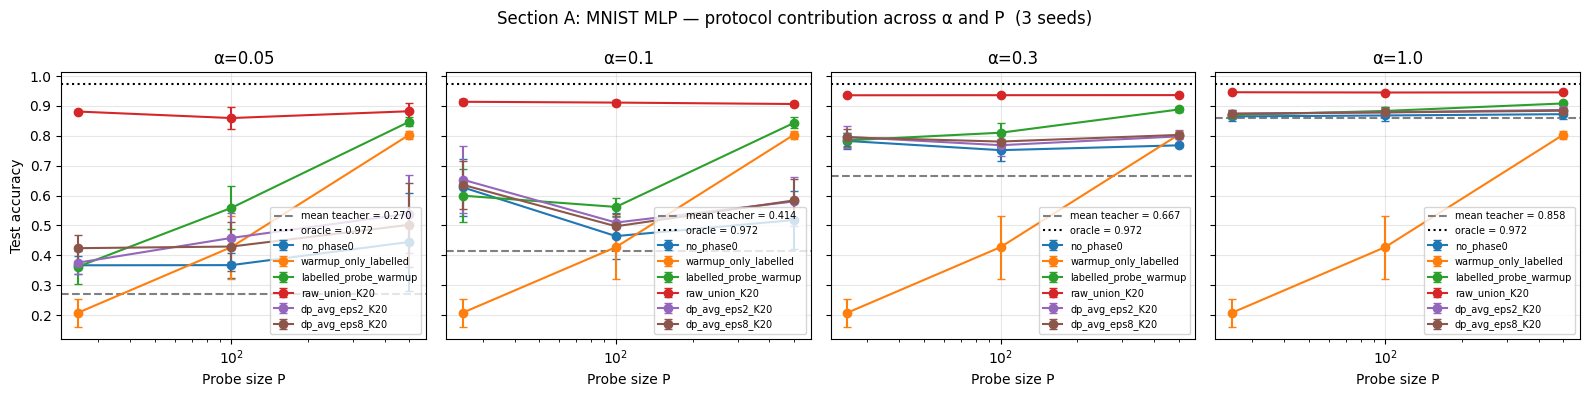

Wrote /content/he_ifd_output/figures/section_A_protocol_surface.png

Protocol contribution table:
 alpha  probe_size     no_phase0 warmup_only_labelled labelled_probe_warmup raw_union_K20 dp_avg_eps2_K20 dp_avg_eps8_K20 best_protocol_minus_warmup_only
  0.05          25 0.367 ± 0.031        0.208 ± 0.048         0.362 ± 0.058 0.881 ± 0.004   0.375 ± 0.039   0.424 ± 0.043                          +0.674
  0.05         100 0.367 ± 0.042        0.427 ± 0.105         0.559 ± 0.072 0.860 ± 0.036   0.458 ± 0.082   0.429 ± 0.082                          +0.432
  0.05         500 0.445 ± 0.163        0.804 ± 0.013         0.848 ± 0.016 0.882 ± 0.028   0.540 ± 0.131   0.502 ± 0.141                          +0.078
  0.10          25 0.628 ± 0.095        0.208 ± 0.048         0.600 ± 0.090 0.914 ± 0.009   0.654 ± 0.111   0.636 ± 0.080                          +0.707
  0.10         100 0.464 ± 0.078        0.427 ± 0.105         0.562 ± 0.031 0.911 ± 0.007   0.510 ± 0.020   0.497 ± 0.040           

In [8]:

# # Section A: From-scratch MNIST MLP
#
# Goal: show the protocol's behavior in the from-scratch training regime.
# Three things to demonstrate:
#
# 1. **Probe alone is sometimes a strong baseline on easy benchmarks.**
#    On MNIST + small MLP, even a P=200 labelled probe trained for 5 epochs
#    can match mean-teacher accuracy. The paper should not hide this — it
#    should show it, and explain that this is *why* the protocol's value
#    must be measured by what it adds *on top* of every probe size, not just
#    by what it produces in isolation.
#
# 2. **The protocol's contribution surface scales with heterogeneity and
#    inversely with probe size.** Smaller probe + higher heterogeneity =
#    larger protocol contribution.
#
# 3. **DP-aligned synthetic probe matches labelled probe.** The averaging
#    variant at moderate ε produces a Phase-0 init nearly as useful as a
#    real labelled probe of the same nominal size.


# ## Section A.1: MNIST data load

# %%
def get_mnist():
    cache = DIRS["features"] / "mnist.pt"
    if cache.exists():
        d = torch.load(cache)
        return d["X_train"], d["y_train"], d["X_test"], d["y_test"]
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    train_ds = datasets.MNIST("./data", train=True, download=True, transform=tfm)
    test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)
    X_train = torch.stack([train_ds[i][0] for i in range(len(train_ds))]).view(-1, 784)
    y_train = torch.tensor([train_ds[i][1] for i in range(len(train_ds))])
    X_test  = torch.stack([test_ds[i][0] for i in range(len(test_ds))]).view(-1, 784)
    y_test  = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])
    torch.save({"X_train": X_train, "y_train": y_train,
                "X_test": X_test, "y_test": y_test}, cache)
    return X_train, y_train, X_test, y_test

X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist = get_mnist()
X_test_mnist_dev = X_test_mnist.to(DEVICE)
y_test_mnist_dev = y_test_mnist.to(DEVICE)
print(f"MNIST: train {X_train_mnist.shape}, test {X_test_mnist.shape}")



# ## Section A.2: MLP definitions

# %%
class MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x): return self.net(x)


def make_mnist_mlp():
    return MLP_MNIST().to(DEVICE)



# ## Section A.3: Run section A
#
# 5 methods × 4 alphas × 4 probe sizes × 3 seeds = 240 runs.
# Each run is ~10 s.  Total ~40 min on T4.

# %%
SECTION_A_PROBE_SIZES = [25, 100, 500]
SECTION_A_METHODS = [
    # ("method_name", "phase0_kind", phase0_kwargs)
    ("no_phase0",              "none",          {}),
    ("warmup_only_labelled",   "warmup_only",   {}),
    ("labelled_probe_warmup",  "labelled",      {}),
    ("raw_union_K20",          "raw_union",     {"K_per_class": 20}),
    ("dp_avg_eps2_K20",        "dp_avg",        {"K_per_class": 20, "eps": 2.0}),
    ("dp_avg_eps8_K20",        "dp_avg",        {"K_per_class": 20, "eps": 8.0}),
]
NUM_CLASSES_MNIST = 10


def run_section_A_task(seed, alpha, probe_size, method_name, phase0_kind, phase0_kwargs):
    """One task: returns dict with acc and references."""
    # Reserve labelled probe (deterministic per seed for reproducibility)
    rng = np.random.default_rng(seed)
    probe_idx = rng.choice(len(X_train_mnist), probe_size, replace=False)
    probe_mask = np.zeros(len(X_train_mnist), dtype=bool)
    probe_mask[probe_idx] = True
    probe_X = X_train_mnist[probe_idx]
    probe_y = y_train_mnist[probe_idx]
    pool_X = X_train_mnist[~probe_mask]
    pool_y = y_train_mnist[~probe_mask]

    # Dirichlet partition the pool across clients
    client_idx = dirichlet_partition(pool_y.numpy(), N_CLIENTS, alpha, seed, NUM_CLASSES_MNIST)
    client_X_list = [pool_X[ci] for ci in client_idx]
    client_y_list = [pool_y[ci] for ci in client_idx]
    sample_sizes = [len(ci) for ci in client_idx]

    # Train teachers
    teachers, t_accs = [], []
    for i in range(N_CLIENTS):
        if sample_sizes[i] == 0:
            teachers.append(make_mnist_mlp())
            t_accs.append(1.0 / NUM_CLASSES_MNIST)
            continue
        t = train_supervised_model(make_mnist_mlp, client_X_list[i], client_y_list[i],
                                     epochs=TEACHER_EPOCHS, lr=TEACHER_LR,
                                     momentum=TEACHER_MOMENTUM, bs=BS,
                                     seed=seed * 1000 + i)
        teachers.append(t)
        t_accs.append(accuracy_on(t, X_test_mnist_dev, y_test_mnist_dev))
    mean_teacher = float(np.mean(t_accs))
    best_teacher = float(np.max(t_accs))

    # Oracle (centralised on entire pool)
    oracle_m = train_supervised_model(make_mnist_mlp, pool_X, pool_y,
                                       epochs=ORACLE_EPOCHS, lr=TEACHER_LR,
                                       momentum=TEACHER_MOMENTUM, bs=BS,
                                       seed=seed * 7919)
    oracle_acc = accuracy_on(oracle_m, X_test_mnist_dev, y_test_mnist_dev)

    # Shared init
    torch.manual_seed(seed)
    init_params = get_params(make_mnist_mlp())

    # For DP methods, compute clip on the (public) pool of training data
    if phase0_kind == "dp_avg":
        clip = compute_feature_norms_percentile(pool_X)
    else:
        clip = None

    # Defaults that every branch can override
    probe_size_actual = 0
    info = {"probe_size": 0, "sigma": 0.0}

    # Build phase-0 init based on the method
    if phase0_kind == "none":
        phase0_init = init_params
        # probe_size_actual stays 0; info stays default
    elif phase0_kind == "warmup_only":
        warmed = train_supervised_model(make_mnist_mlp, probe_X, probe_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR,
                                          momentum=TEACHER_MOMENTUM, bs=BS,
                                          seed=12345, init_params=init_params)
        # This method's "result" IS the warmup-only model; no distillation
        acc = accuracy_on(warmed, X_test_mnist_dev, y_test_mnist_dev)
        return {
            "acc": acc, "mean_teacher": mean_teacher,
            "best_teacher": best_teacher, "oracle": oracle_acc,
            "probe_size_actual": int(probe_size),
            "sigma": 0.0, "method_name": method_name,
        }
    elif phase0_kind == "labelled":
        warmed = train_supervised_model(make_mnist_mlp, probe_X, probe_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR,
                                          momentum=TEACHER_MOMENTUM, bs=BS,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
        probe_size_actual = probe_size
        info = {"probe_size": probe_size, "sigma": 0.0}
    elif phase0_kind == "raw_union":
        align_probe_X, align_probe_y, info = build_probe_raw_union(
            client_X_list, client_y_list, phase0_kwargs["K_per_class"],
            NUM_CLASSES_MNIST, seed=seed * 100003,
        )
        warmed = train_supervised_model(make_mnist_mlp, align_probe_X, align_probe_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR,
                                          momentum=TEACHER_MOMENTUM, bs=BS,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
        probe_size_actual = info["probe_size"]
    elif phase0_kind == "dp_avg":
        align_probe_X, align_probe_y, info = build_probe_dp_averaged(
            client_X_list, client_y_list, phase0_kwargs["K_per_class"],
            NUM_CLASSES_MNIST, clip=clip, eps_per_client=phase0_kwargs["eps"],
            seed=seed * 100003,
        )
        warmed = train_supervised_model(make_mnist_mlp, align_probe_X, align_probe_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR,
                                          momentum=TEACHER_MOMENTUM, bs=BS,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
        probe_size_actual = info["probe_size"]
    else:
        raise ValueError(phase0_kind)

    # Run the encrypted protocol from the chosen init
    acc, _ = run_protocol_from_init(
        phase0_init, teachers, client_X_list, sample_sizes, make_mnist_mlp,
        X_test_mnist_dev, y_test_mnist_dev, K_DISTILL_STEPS,
        STUDENT_LR, 0.0, TAU, BS,
    )

    return {
        "acc": acc, "mean_teacher": mean_teacher,
        "best_teacher": best_teacher, "oracle": oracle_acc,
        "probe_size_actual": int(probe_size_actual),
        "sigma": float(info.get("sigma", 0.0)),
        "method_name": method_name,
    }

def run_section_A():
    section_t0 = time.time()
    total_tasks = (len(SEEDS) * len(ALPHAS) * len(SECTION_A_PROBE_SIZES)
                   * len(SECTION_A_METHODS))
    done_at_start = sum(1 for k in results
                         if results[k]["descriptor"].get("section") == "A")
    log_status("A", f"Total tasks: {total_tasks}; "
                       f"already completed: {done_at_start}")

    for seed in SEEDS:
        for alpha in ALPHAS:
            for probe_size in SECTION_A_PROBE_SIZES:
                for method_name, phase0_kind, phase0_kwargs in SECTION_A_METHODS:
                    descriptor = {
                        "section": "A",
                        "seed": seed, "alpha": alpha,
                        "probe_size": probe_size,
                        "method_name": method_name,
                        "phase0_kind": phase0_kind,
                        "phase0_kwargs": phase0_kwargs,
                    }
                    if task_done(results, descriptor):
                        continue
                    t0 = time.time()
                    result = run_section_A_task(
                        seed, alpha, probe_size,
                        method_name, phase0_kind, phase0_kwargs,
                    )
                    record_task(results, descriptor, result)
                    log_status("A", f"seed={seed} α={alpha} P={probe_size} "
                                        f"{method_name}: acc={result['acc']:.4f} "
                                        f"({time.time()-t0:.1f}s)")
    log_status("A", f"Section A complete in {(time.time()-section_t0)/60:.1f} min")


run_section_A()


# =====================================================================

# ## Section A.4: Tables and figures for Section A

# %%
def section_A_tables_and_figures():
    df = summary_table(results, filter_section="A")
    if len(df) == 0:
        print("Section A has no completed tasks yet.")
        return
    df["acc"] = df["acc"].astype(float)
    # Aggregate across seeds
    agg = df.groupby(["alpha", "probe_size", "method_name"])["acc"].agg(["mean", "std", "count"]).reset_index()

    # Table A1: acc grid (alpha × probe_size × method)
    out = DIRS["tables"] / "section_A_acc_grid.csv"
    agg.to_csv(out, index=False)
    print(f"Wrote {out}")

    # Figure A1: protocol contribution surface
    fig, axes = plt.subplots(1, len(ALPHAS), figsize=(4*len(ALPHAS), 4), sharey=True)
    for ax, alpha in zip(axes, ALPHAS):
        sub = agg[agg["alpha"] == alpha]
        for method in [m[0] for m in SECTION_A_METHODS]:
            ms = sub[sub["method_name"] == method].sort_values("probe_size")
            if len(ms) == 0:
                continue
            ax.errorbar(ms["probe_size"], ms["mean"], yerr=ms["std"],
                          marker="o", label=method, capsize=3)
        # References
        ref = df[df["alpha"] == alpha].drop_duplicates(subset=["seed"])
        ax.axhline(ref["mean_teacher"].mean(), color="gray", linestyle="--",
                     label=f"mean teacher = {ref['mean_teacher'].mean():.3f}")
        ax.axhline(ref["oracle"].mean(), color="black", linestyle=":",
                     label=f"oracle = {ref['oracle'].mean():.3f}")
        ax.set_xlabel("Probe size P")
        ax.set_xscale("log")
        ax.set_title(f"α={alpha}")
        ax.grid(alpha=0.3)
        if ax is axes[0]:
            ax.set_ylabel("Test accuracy")
        ax.legend(loc="lower right", fontsize=7)
    fig.suptitle(f"Section A: MNIST MLP — protocol contribution across α and P  "
                   f"({len(SEEDS)} seeds)")
    fig.tight_layout()
    out = DIRS["figures"] / "section_A_protocol_surface.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out}")

    # Table A2: best-method per (alpha, probe_size) and its delta vs warmup_only
    deltas = []
    for alpha in ALPHAS:
        for P in SECTION_A_PROBE_SIZES:
            sub = agg[(agg["alpha"] == alpha) & (agg["probe_size"] == P)]
            if len(sub) == 0:
                continue
            row = {"alpha": alpha, "probe_size": P}
            for m in [x[0] for x in SECTION_A_METHODS]:
                ms = sub[sub["method_name"] == m]
                if len(ms):
                    row[m] = f"{ms['mean'].iloc[0]:.3f} ± {ms['std'].iloc[0]:.3f}"
            # Compute protocol contribution = best protocol method - warmup_only
            wo = sub[sub["method_name"] == "warmup_only_labelled"]["mean"]
            protocol_methods = sub[sub["method_name"].isin(
                ["raw_union_K20", "labelled_probe_warmup",
                 "dp_avg_eps2_K20", "dp_avg_eps8_K20"])]
            if len(wo) and len(protocol_methods):
                best_protocol = protocol_methods["mean"].max()
                row["best_protocol_minus_warmup_only"] = f"{best_protocol - wo.iloc[0]:+.3f}"
            deltas.append(row)
    delta_df = pd.DataFrame(deltas)
    out = DIRS["tables"] / "section_A_protocol_contribution.csv"
    delta_df.to_csv(out, index=False)
    print(f"\nProtocol contribution table:")
    print(delta_df.to_string(index=False))


section_A_tables_and_figures()


# =====================================================================


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]
100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]


[B] Extracting resnet18 features (this is one-time)
[B]   cached /content/he_ifd_output/features/cifar10_resnet18.pt in 109.3s


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

[B] Extracting vit_b32 features (this is one-time)
[B]   cached /content/he_ifd_output/features/cifar10_vit_b32.pt in 182.7s
[B] Total tasks: 120; already done: 0
[B] backbone=resnet18 clip=32.75
[B]   resnet18 seed=42 α=0.05 no_phase0: acc=0.2109 (9.9s)
[B]   resnet18 seed=42 α=0.05 labelled_probe_warmup: acc=0.2316 (9.4s)
[B]   resnet18 seed=42 α=0.05 raw_union_K20: acc=0.5293 (10.3s)
[B]   resnet18 seed=42 α=0.05 dp_avg_eps2_K20: acc=0.2184 (10.8s)
[B]   resnet18 seed=42 α=0.05 dp_avg_eps8_K20: acc=0.2285 (10.7s)
[B]   resnet18 seed=42 α=0.1 no_phase0: acc=0.3210 (10.2s)
[B]   resnet18 seed=42 α=0.1 labelled_probe_warmup: acc=0.3469 (9.7s)
[B]   resnet18 seed=42 α=0.1 raw_union_K20: acc=0.6209 (9.7s)
[B]   resnet18 seed=42 α=0.1 dp_avg_eps2_K20: acc=0.3309 (10.2s)
[B]   resnet18 seed=42 α=0.1 dp_avg_eps8_K20: acc=0.3446 (9.7s)
[B]   resnet18 seed=42 α=0.3 no_phase0: acc=0.6299 (9.7s)
[B]   resnet18 seed=42 α=0.3 labelled_probe_warmup: acc=0.6552 (10.3s)
[B]   resnet18 seed=42 α=0.3 

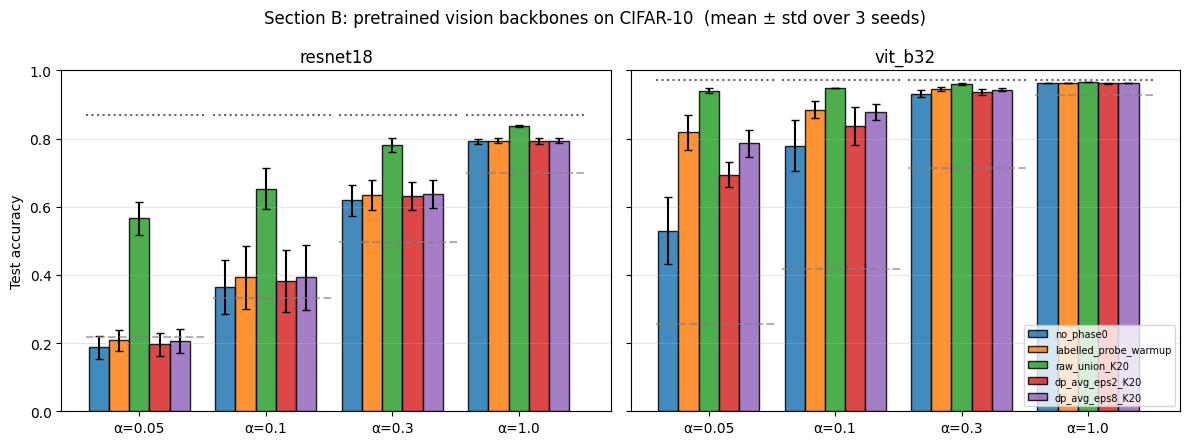

Wrote /content/he_ifd_output/figures/section_B_vision_comparison.png


In [9]:

# # Section B: Pretrained vision backbones
#
# Two backbones (ResNet-18 ImageNet-pretrained, ViT-B/32 ImageNet-pretrained),
# CIFAR-10, head-only training. Tests whether the protocol's findings from
# MNIST transfer to the modern deployment setting where everyone shares a
# pretrained backbone.


# ## Section B.1: Feature extractors

# %%
def build_resnet18_extractor():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity()
    return m.to(DEVICE).eval(), 512


def build_vit_extractor():
    import timm
    m = timm.create_model("vit_base_patch32_224", pretrained=True, num_classes=0)
    return m.to(DEVICE).eval(), m.num_features


def extract_cifar10_features(backbone_name):
    cache = DIRS["features"] / f"cifar10_{backbone_name}.pt"
    if cache.exists():
        d = torch.load(cache)
        return d["X_train"], d["y_train"], d["X_test"], d["y_test"], d["in_dim"]

    if backbone_name == "resnet18":
        extractor, in_dim = build_resnet18_extractor()
        tfm = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    elif backbone_name == "vit_b32":
        extractor, in_dim = build_vit_extractor()
        tfm = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
    else:
        raise ValueError(backbone_name)

    train_ds = datasets.CIFAR10("./data", train=True,  download=True, transform=tfm)
    test_ds  = datasets.CIFAR10("./data", train=False, download=True, transform=tfm)

    def collate(ds):
        loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2)
        feats, labels = [], []
        with torch.no_grad():
            for x, y in loader:
                f = extractor(x.to(DEVICE)).cpu()
                feats.append(f); labels.append(y)
        return torch.cat(feats), torch.cat(labels)

    log_status("B", f"Extracting {backbone_name} features (this is one-time)")
    t0 = time.time()
    X_train, y_train = collate(train_ds)
    X_test,  y_test  = collate(test_ds)
    torch.save({"X_train": X_train, "y_train": y_train,
                "X_test": X_test, "y_test": y_test, "in_dim": in_dim}, cache)
    log_status("B", f"  cached {cache} in {(time.time()-t0):.1f}s")
    del extractor
    torch.cuda.empty_cache()
    return X_train, y_train, X_test, y_test, in_dim



# ## Section B.2: Head model + section runner

# %%
class ClassifierHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)
    def forward(self, x): return self.fc(x)


def make_head(in_dim, num_classes):
    def _():
        return ClassifierHead(in_dim, num_classes).to(DEVICE)
    return _


SECTION_B_METHODS = [
    ("no_phase0",              "none",          {}),
    ("labelled_probe_warmup",  "labelled",      {}),
    ("raw_union_K20",          "raw_union",     {"K_per_class": 20}),
    ("dp_avg_eps2_K20",        "dp_avg",        {"K_per_class": 20, "eps": 2.0}),
    ("dp_avg_eps8_K20",        "dp_avg",        {"K_per_class": 20, "eps": 8.0}),
]
SECTION_B_LABELLED_PROBE_P = 100


def run_pretrained_protocol_task(section_name, backbone_label, X_train_feat, y_train_feat,
                                    X_test_feat, y_test_feat, in_dim, num_classes,
                                    seed, alpha, method_name, phase0_kind,
                                    phase0_kwargs, clip):
    """Run one protocol task on pretrained features.  Shared between B and C."""
    rng = np.random.default_rng(seed)
    probe_idx = rng.choice(len(X_train_feat), SECTION_B_LABELLED_PROBE_P, replace=False)
    probe_mask = np.zeros(len(X_train_feat), dtype=bool)
    probe_mask[probe_idx] = True
    probe_X = X_train_feat[probe_idx]
    probe_y = y_train_feat[probe_idx]
    pool_X = X_train_feat[~probe_mask]
    pool_y = y_train_feat[~probe_mask]

    client_idx = dirichlet_partition(pool_y.numpy(), N_CLIENTS, alpha, seed, num_classes)
    client_X_list = [pool_X[ci] for ci in client_idx]
    client_y_list = [pool_y[ci] for ci in client_idx]
    sample_sizes = [len(ci) for ci in client_idx]

    head_factory = make_head(in_dim, num_classes)

    teachers, t_accs = [], []
    for i in range(N_CLIENTS):
        if sample_sizes[i] == 0:
            teachers.append(head_factory())
            t_accs.append(1.0 / num_classes)
            continue
        t = train_supervised_model(head_factory, client_X_list[i], client_y_list[i],
                                     epochs=TEACHER_EPOCHS_HEAD, lr=TEACHER_LR_HEAD,
                                     momentum=TEACHER_MOMENTUM, bs=BS_HEAD,
                                     seed=seed * 1000 + i)
        teachers.append(t)
        t_accs.append(accuracy_on(t, X_test_feat.to(DEVICE), y_test_feat.to(DEVICE)))
    mean_teacher = float(np.mean(t_accs))
    best_teacher = float(np.max(t_accs))

    oracle_m = train_supervised_model(head_factory, pool_X, pool_y,
                                       epochs=ORACLE_EPOCHS_HEAD, lr=TEACHER_LR_HEAD,
                                       momentum=TEACHER_MOMENTUM, bs=BS_HEAD,
                                       seed=seed * 7919)
    oracle_acc = accuracy_on(oracle_m, X_test_feat.to(DEVICE), y_test_feat.to(DEVICE))

    torch.manual_seed(seed)
    init_params = get_params(head_factory())

    if phase0_kind == "none":
        phase0_init = init_params
        info = {"probe_size": 0, "sigma": 0.0}
    elif phase0_kind == "labelled":
        warmed = train_supervised_model(head_factory, probe_X, probe_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR_HEAD,
                                          momentum=TEACHER_MOMENTUM, bs=BS_HEAD,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
        info = {"probe_size": SECTION_B_LABELLED_PROBE_P, "sigma": 0.0}
    elif phase0_kind == "raw_union":
        align_X, align_y, info = build_probe_raw_union(
            client_X_list, client_y_list, phase0_kwargs["K_per_class"],
            num_classes, seed=seed * 100003,
        )
        warmed = train_supervised_model(head_factory, align_X, align_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR_HEAD,
                                          momentum=TEACHER_MOMENTUM, bs=BS_HEAD,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
    elif phase0_kind == "dp_avg":
        align_X, align_y, info = build_probe_dp_averaged(
            client_X_list, client_y_list, phase0_kwargs["K_per_class"],
            num_classes, clip=clip, eps_per_client=phase0_kwargs["eps"],
            seed=seed * 100003,
        )
        warmed = train_supervised_model(head_factory, align_X, align_y,
                                          epochs=WARMUP_EPOCHS, lr=TEACHER_LR_HEAD,
                                          momentum=TEACHER_MOMENTUM, bs=BS_HEAD,
                                          seed=12345, init_params=init_params)
        phase0_init = get_params(warmed)
    else:
        raise ValueError(phase0_kind)

    acc, _ = run_protocol_from_init(
        phase0_init, teachers, client_X_list, sample_sizes, head_factory,
        X_test_feat.to(DEVICE), y_test_feat.to(DEVICE), K_DISTILL_STEPS,
        STUDENT_LR, 0.0, TAU, BS_HEAD,
    )

    return {
        "acc": acc, "mean_teacher": mean_teacher,
        "best_teacher": best_teacher, "oracle": oracle_acc,
        "probe_size_actual": info["probe_size"], "sigma": info["sigma"],
        "method_name": method_name, "backbone": backbone_label,
    }


def run_section_B():
    section_t0 = time.time()
    backbones = ["resnet18", "vit_b32"]
    feature_caches = {}
    for bb in backbones:
        feature_caches[bb] = extract_cifar10_features(bb)

    total = len(SEEDS) * len(ALPHAS) * len(SECTION_B_METHODS) * len(backbones)
    done = sum(1 for k in results if results[k]["descriptor"].get("section") == "B")
    log_status("B", f"Total tasks: {total}; already done: {done}")

    for bb in backbones:
        X_tr, y_tr, X_te, y_te, in_dim = feature_caches[bb]
        clip = compute_feature_norms_percentile(X_tr)
        log_status("B", f"backbone={bb} clip={clip:.2f}")
        for seed in SEEDS:
            for alpha in ALPHAS:
                for method_name, kind, kwargs in SECTION_B_METHODS:
                    descriptor = {
                        "section": "B", "backbone": bb,
                        "seed": seed, "alpha": alpha,
                        "method_name": method_name,
                        "phase0_kind": kind, "phase0_kwargs": kwargs,
                    }
                    if task_done(results, descriptor):
                        continue
                    t0 = time.time()
                    result = run_pretrained_protocol_task(
                        "B", bb, X_tr, y_tr, X_te, y_te, in_dim,
                        num_classes=10, seed=seed, alpha=alpha,
                        method_name=method_name, phase0_kind=kind,
                        phase0_kwargs=kwargs, clip=clip,
                    )
                    record_task(results, descriptor, result)
                    log_status("B", f"  {bb} seed={seed} α={alpha} {method_name}: "
                                       f"acc={result['acc']:.4f} ({time.time()-t0:.1f}s)")
    log_status("B", f"Section B complete in {(time.time()-section_t0)/60:.1f} min")


run_section_B()



# ## Section B.3: Tables and figures for Section B

# %%
def section_B_tables_and_figures():
    df = summary_table(results, filter_section="B")
    if len(df) == 0:
        print("Section B has no completed tasks yet.")
        return
    df["acc"] = df["acc"].astype(float)
    agg = df.groupby(["backbone", "alpha", "method_name"])["acc"].agg(
        ["mean", "std", "count"]).reset_index()

    out = DIRS["tables"] / "section_B_acc_grid.csv"
    agg.to_csv(out, index=False)
    print(f"Wrote {out}")

    # Figure B1: grouped bar chart per backbone
    backbones = df["backbone"].unique()
    fig, axes = plt.subplots(1, len(backbones), figsize=(6*len(backbones), 4.5),
                               sharey=True)
    if len(backbones) == 1:
        axes = [axes]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    for ax, bb in zip(axes, backbones):
        sub = agg[agg["backbone"] == bb]
        method_order = [m[0] for m in SECTION_B_METHODS]
        x = np.arange(len(ALPHAS))
        width = 0.8 / len(method_order)
        for i, m in enumerate(method_order):
            vals, errs = [], []
            for a in ALPHAS:
                row = sub[(sub["alpha"] == a) & (sub["method_name"] == m)]
                vals.append(row["mean"].iloc[0] if len(row) else np.nan)
                errs.append(row["std"].iloc[0] if len(row) else 0)
            ax.bar(x + i*width, vals, width, yerr=errs, color=colors[i],
                     label=m, capsize=3, alpha=0.85, edgecolor="k")
        # References
        for j, a in enumerate(ALPHAS):
            ref = df[(df["backbone"] == bb) & (df["alpha"] == a)
                       ].drop_duplicates(subset=["seed"])
            if len(ref):
                ax.hlines(ref["mean_teacher"].mean(), j-0.1, j+0.85,
                            color="gray", linestyle="--", alpha=0.6)
                ax.hlines(ref["oracle"].mean(), j-0.1, j+0.85,
                            color="black", linestyle=":", alpha=0.6)
        ax.set_xticks(x + 2 * width)
        ax.set_xticklabels([f"α={a}" for a in ALPHAS])
        ax.set_title(bb)
        ax.set_ylim([0, 1.0])
        ax.grid(alpha=0.3, axis="y")
        if ax is axes[0]:
            ax.set_ylabel("Test accuracy")
    axes[-1].legend(loc="lower right", fontsize=7)
    fig.suptitle(f"Section B: pretrained vision backbones on CIFAR-10  "
                   f"(mean ± std over {len(SEEDS)} seeds)")
    fig.tight_layout()
    out = DIRS["figures"] / "section_B_vision_comparison.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out}")


section_B_tables_and_figures()


# =====================================================================


[C] Loading distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[C]   Extracting gpt2_small features on ag_news train...
[C]   cached /content/he_ifd_output/features/ag_news_gpt2_small.pt in 773.0s
[C] Total tasks: 120; already done: 0
[C] backbone=distilbert clip=8.56
[C]   distilbert seed=42 α=0.05 no_phase0: acc=0.3245 (14.4s)
[C]   distilbert seed=42 α=0.05 labelled_probe_warmup: acc=0.4076 (14.7s)
[C]   distilbert seed=42 α=0.05 raw_union_K20: acc=0.6778 (14.3s)
[C]   distilbert seed=42 α=0.05 dp_avg_eps2_K20: acc=0.3911 (14.8s)
[C]   distilbert seed=42 α=0.05 dp_avg_eps8_K20: acc=0.4099 (14.6s)
[C]   distilbert seed=42 α=0.1 no_phase0: acc=0.3195 (14.9s)
[C]   distilbert seed=42 α=0.1 labelled_probe_warmup: acc=0.3291 (14.3s)
[C]   distilbert seed=42 α=0.1 raw_union_K20: acc=0.5907 (14.6s)
[C]   distilbert seed=42 α=0.1 dp_avg_eps2_K20: acc=0.3330 (14.2s)
[C]   distilbert seed=42 α=0.1 dp_avg_eps8_K20: acc=0.3342 (14.7s)
[C]   distilbert seed=42 α=0.3 no_phase0: acc=0.7593 (14.5s)
[C]   distilbert seed=42 α=0.3 labelled_probe_warmup: acc=0.77

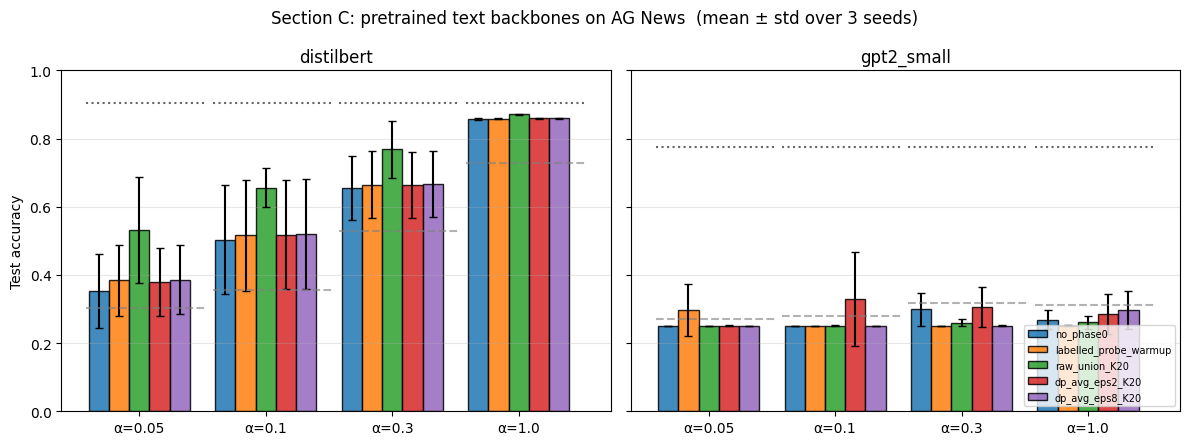

Wrote /content/he_ifd_output/figures/section_C_text_comparison.png


In [10]:

# # Section C: Pretrained text backbones
#
# DistilBERT and GPT-2 on AG News. Same protocol, two architectures.


# ## Section C.1: Feature extractors

# %%
def extract_text_features(backbone_name, task_name="ag_news"):
    """Returns X_train, y_train, X_test, y_test, in_dim. Cached to disk."""
    cache = DIRS["features"] / f"{task_name}_{backbone_name}.pt"
    if cache.exists():
        d = torch.load(cache)
        return d["X_train"], d["y_train"], d["X_test"], d["y_test"], d["in_dim"]

    from transformers import AutoTokenizer, AutoModel
    from datasets import load_dataset

    if backbone_name == "distilbert":
        model_id = "distilbert-base-uncased"
    elif backbone_name == "gpt2_small":
        model_id = "gpt2"
    else:
        raise ValueError(backbone_name)

    log_status("C", f"Loading {model_id}...")
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    model = AutoModel.from_pretrained(model_id).to(DEVICE).eval()
    in_dim = model.config.hidden_size if hasattr(model.config, "hidden_size") else 768

    ds = load_dataset(task_name)
    train_texts = ds["train"]["text"]
    train_labels = torch.tensor(ds["train"]["label"], dtype=torch.long)
    test_texts = ds["test"]["text"]
    test_labels = torch.tensor(ds["test"]["label"], dtype=torch.long)

    def extract(texts, bs=32, max_len=128):
        feats = []
        with torch.no_grad():
            for i in range(0, len(texts), bs):
                batch = texts[i:i+bs]
                enc = tok(batch, padding=True, truncation=True, max_length=max_len,
                            return_tensors="pt").to(DEVICE)
                out = model(**enc)
                last = out.last_hidden_state
                mask = enc["attention_mask"].unsqueeze(-1).float()
                pooled = (last * mask).sum(1) / mask.sum(1).clamp_min(1)
                feats.append(pooled.cpu())
        return torch.cat(feats)

    log_status("C", f"  Extracting {backbone_name} features on {task_name} train...")
    t0 = time.time()
    X_train = extract(train_texts)
    X_test  = extract(test_texts)
    torch.save({"X_train": X_train, "y_train": train_labels,
                "X_test": X_test, "y_test": test_labels, "in_dim": in_dim}, cache)
    log_status("C", f"  cached {cache} in {time.time()-t0:.1f}s")
    del model
    torch.cuda.empty_cache()
    return X_train, train_labels, X_test, test_labels, in_dim



# ## Section C.2: Run section C

# %%
SECTION_C_METHODS = SECTION_B_METHODS  # same panel for direct comparison


def run_section_C():
    section_t0 = time.time()
    backbones = ["distilbert", "gpt2_small"]
    num_classes = 4

    feature_caches = {}
    for bb in backbones:
        feature_caches[bb] = extract_text_features(bb, "ag_news")

    total = len(SEEDS) * len(ALPHAS) * len(SECTION_C_METHODS) * len(backbones)
    done = sum(1 for k in results if results[k]["descriptor"].get("section") == "C")
    log_status("C", f"Total tasks: {total}; already done: {done}")

    for bb in backbones:
        X_tr, y_tr, X_te, y_te, in_dim = feature_caches[bb]
        clip = compute_feature_norms_percentile(X_tr)
        log_status("C", f"backbone={bb} clip={clip:.2f}")
        for seed in SEEDS:
            for alpha in ALPHAS:
                for method_name, kind, kwargs in SECTION_C_METHODS:
                    descriptor = {
                        "section": "C", "backbone": bb,
                        "seed": seed, "alpha": alpha,
                        "method_name": method_name,
                        "phase0_kind": kind, "phase0_kwargs": kwargs,
                    }
                    if task_done(results, descriptor):
                        continue
                    t0 = time.time()
                    result = run_pretrained_protocol_task(
                        "C", bb, X_tr, y_tr, X_te, y_te, in_dim,
                        num_classes=num_classes, seed=seed, alpha=alpha,
                        method_name=method_name, phase0_kind=kind,
                        phase0_kwargs=kwargs, clip=clip,
                    )
                    record_task(results, descriptor, result)
                    log_status("C", f"  {bb} seed={seed} α={alpha} {method_name}: "
                                       f"acc={result['acc']:.4f} ({time.time()-t0:.1f}s)")
    log_status("C", f"Section C complete in {(time.time()-section_t0)/60:.1f} min")


run_section_C()



# ## Section C.3: Tables and figures for Section C

# %%
def section_C_tables_and_figures():
    df = summary_table(results, filter_section="C")
    if len(df) == 0:
        print("Section C has no completed tasks yet.")
        return
    df["acc"] = df["acc"].astype(float)
    agg = df.groupby(["backbone", "alpha", "method_name"])["acc"].agg(
        ["mean", "std", "count"]).reset_index()

    out = DIRS["tables"] / "section_C_acc_grid.csv"
    agg.to_csv(out, index=False)
    print(f"Wrote {out}")

    backbones = df["backbone"].unique()
    fig, axes = plt.subplots(1, len(backbones), figsize=(6*len(backbones), 4.5),
                               sharey=True)
    if len(backbones) == 1:
        axes = [axes]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    for ax, bb in zip(axes, backbones):
        sub = agg[agg["backbone"] == bb]
        method_order = [m[0] for m in SECTION_C_METHODS]
        x = np.arange(len(ALPHAS))
        width = 0.8 / len(method_order)
        for i, m in enumerate(method_order):
            vals, errs = [], []
            for a in ALPHAS:
                row = sub[(sub["alpha"] == a) & (sub["method_name"] == m)]
                vals.append(row["mean"].iloc[0] if len(row) else np.nan)
                errs.append(row["std"].iloc[0] if len(row) else 0)
            ax.bar(x + i*width, vals, width, yerr=errs, color=colors[i],
                     label=m, capsize=3, alpha=0.85, edgecolor="k")
        for j, a in enumerate(ALPHAS):
            ref = df[(df["backbone"] == bb) & (df["alpha"] == a)
                       ].drop_duplicates(subset=["seed"])
            if len(ref):
                ax.hlines(ref["mean_teacher"].mean(), j-0.1, j+0.85,
                            color="gray", linestyle="--", alpha=0.6)
                ax.hlines(ref["oracle"].mean(), j-0.1, j+0.85,
                            color="black", linestyle=":", alpha=0.6)
        ax.set_xticks(x + 2 * width)
        ax.set_xticklabels([f"α={a}" for a in ALPHAS])
        ax.set_title(bb)
        ax.set_ylim([0, 1.0])
        ax.grid(alpha=0.3, axis="y")
        if ax is axes[0]:
            ax.set_ylabel("Test accuracy")
    axes[-1].legend(loc="lower right", fontsize=7)
    fig.suptitle(f"Section C: pretrained text backbones on AG News  "
                   f"(mean ± std over {len(SEEDS)} seeds)")
    fig.tight_layout()
    out = DIRS["figures"] / "section_C_text_comparison.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out}")


section_C_tables_and_figures()


# =====================================================================


[D] Total tasks: 405; already done: 0
[D] setup=cifar10_vit_b32 clip=52.86
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=0.5 K=1: acc=0.2544 (10.2s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=0.5 K=5: acc=0.3171 (10.4s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=0.5 K=20: acc=0.5384 (10.7s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=2.0 K=1: acc=0.3287 (10.0s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=2.0 K=5: acc=0.5607 (10.6s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=2.0 K=20: acc=0.7017 (10.1s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=8.0 K=1: acc=0.5073 (10.9s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=8.0 K=5: acc=0.6959 (10.5s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=8.0 K=20: acc=0.7773 (10.8s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=32.0 K=1: acc=0.6351 (10.5s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=32.0 K=5: acc=0.7843 (10.9s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=32.0 K=20: acc=0.8043 (10.3s)
[D]   cifar10_vit_b32 seed=42 α=0.05 eps=inf K=1: acc=0.7914 (10.1s)
[D]   cifar10_vit_b32

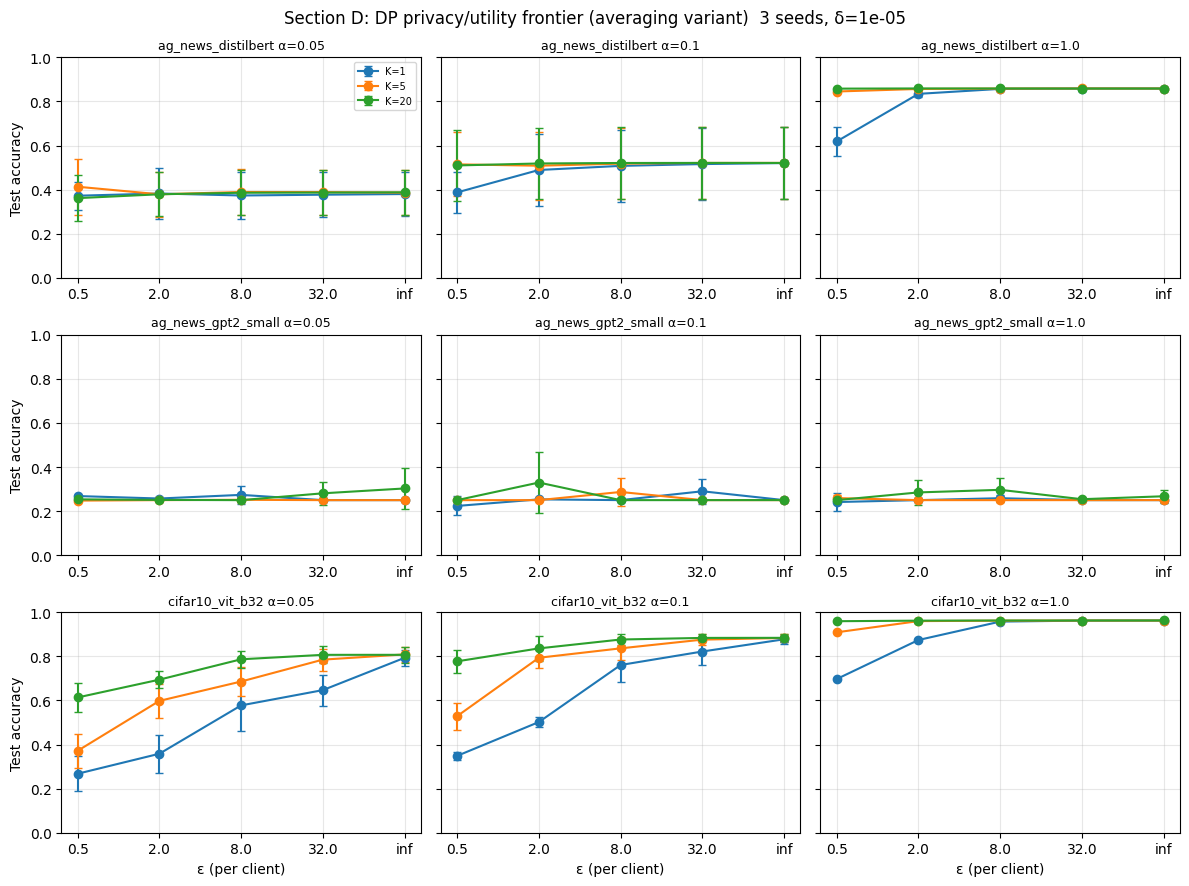

Wrote /content/he_ifd_output/figures/section_D_dp_frontier.png


In [11]:

# # Section D: DP privacy/utility frontier
#
# Sweep (ε, K) at fixed α to characterise the privacy/utility tradeoff of
# the averaging-variant DP alignment. Three setups (ViT, DistilBERT, GPT-2)
# to show modality breadth.

# %%
SECTION_D_SETUPS = [
    ("cifar10_vit_b32", 10),
    ("ag_news_distilbert", 4),
    ("ag_news_gpt2_small", 4),
]
SECTION_D_ALPHAS = [0.05, 0.1, 1.0]
SECTION_D_EPS_VALUES = [0.5, 2.0, 8.0, 32.0, float("inf")]
SECTION_D_K_VALUES = [1, 5, 20]


def run_section_D():
    section_t0 = time.time()
    feature_caches = {}
    for setup_name, num_classes in SECTION_D_SETUPS:
        if setup_name == "cifar10_vit_b32":
            feats = extract_cifar10_features("vit_b32")
        elif setup_name == "ag_news_distilbert":
            feats = extract_text_features("distilbert", "ag_news")
        elif setup_name == "ag_news_gpt2_small":
            feats = extract_text_features("gpt2_small", "ag_news")
        else:
            raise ValueError(setup_name)
        feature_caches[setup_name] = feats

    total = (len(SEEDS) * len(SECTION_D_SETUPS) * len(SECTION_D_ALPHAS)
             * len(SECTION_D_EPS_VALUES) * len(SECTION_D_K_VALUES))
    done = sum(1 for k in results if results[k]["descriptor"].get("section") == "D")
    log_status("D", f"Total tasks: {total}; already done: {done}")

    for setup_name, num_classes in SECTION_D_SETUPS:
        X_tr, y_tr, X_te, y_te, in_dim = feature_caches[setup_name]
        clip = compute_feature_norms_percentile(X_tr)
        log_status("D", f"setup={setup_name} clip={clip:.2f}")
        for seed in SEEDS:
            for alpha in SECTION_D_ALPHAS:
                for eps in SECTION_D_EPS_VALUES:
                    for K_pc in SECTION_D_K_VALUES:
                        method_name = (f"dp_avg_eps{'inf' if eps == float('inf') else eps}"
                                          f"_K{K_pc}")
                        descriptor = {
                            "section": "D", "setup": setup_name,
                            "seed": seed, "alpha": alpha,
                            "method_name": method_name,
                            "phase0_kind": "dp_avg",
                            "phase0_kwargs": {"K_per_class": K_pc, "eps": eps},
                        }
                        if task_done(results, descriptor):
                            continue
                        t0 = time.time()
                        result = run_pretrained_protocol_task(
                            "D", setup_name, X_tr, y_tr, X_te, y_te, in_dim,
                            num_classes=num_classes, seed=seed, alpha=alpha,
                            method_name=method_name, phase0_kind="dp_avg",
                            phase0_kwargs={"K_per_class": K_pc, "eps": eps},
                            clip=clip,
                        )
                        record_task(results, descriptor, result)
                        log_status("D", f"  {setup_name} seed={seed} α={alpha} "
                                           f"eps={eps} K={K_pc}: "
                                           f"acc={result['acc']:.4f} "
                                           f"({time.time()-t0:.1f}s)")
    log_status("D", f"Section D complete in {(time.time()-section_t0)/60:.1f} min")


run_section_D()



# ## Section D.2: Tables and figures for Section D

# %%
def section_D_tables_and_figures():
    df = summary_table(results, filter_section="D")
    if len(df) == 0:
        print("Section D has no completed tasks yet.")
        return
    df["acc"] = df["acc"].astype(float)
    # Extract eps and K from method_name
    df["eps"] = df["method_name"].str.extract(r"eps([^_]+)_K")[0]
    df["K_per_class"] = df["method_name"].str.extract(r"K(\d+)$")[0].astype(int)

    agg = df.groupby(["setup", "alpha", "eps", "K_per_class"])["acc"].agg(
        ["mean", "std", "count"]).reset_index()

    out = DIRS["tables"] / "section_D_dp_frontier.csv"
    agg.to_csv(out, index=False)
    print(f"Wrote {out}")

    setups = sorted(df["setup"].unique())
    eps_order = ["0.5", "2.0", "8.0", "32.0", "inf"]
    fig, axes = plt.subplots(len(setups), len(SECTION_D_ALPHAS),
                               figsize=(4*len(SECTION_D_ALPHAS), 3*len(setups)),
                               squeeze=False, sharey="row")
    for i, setup in enumerate(setups):
        for j, alpha in enumerate(SECTION_D_ALPHAS):
            ax = axes[i][j]
            sub = agg[(agg["setup"] == setup) & (agg["alpha"] == alpha)]
            for K_pc in SECTION_D_K_VALUES:
                row_data = sub[sub["K_per_class"] == K_pc]
                if len(row_data) == 0:
                    continue
                xs, ys, errs = [], [], []
                for e in eps_order:
                    rd = row_data[row_data["eps"] == e]
                    if len(rd):
                        xs.append(e); ys.append(rd["mean"].iloc[0])
                        errs.append(rd["std"].iloc[0])
                ax.errorbar(xs, ys, yerr=errs, marker="o", capsize=3,
                              label=f"K={K_pc}")
            ax.set_title(f"{setup} α={alpha}", fontsize=9)
            ax.grid(alpha=0.3)
            if j == 0:
                ax.set_ylabel("Test accuracy")
            if i == len(setups) - 1:
                ax.set_xlabel("ε (per client)")
            if i == 0 and j == 0:
                ax.legend(fontsize=7)
            ax.set_ylim([0, 1.0])
    fig.suptitle(f"Section D: DP privacy/utility frontier (averaging variant)  "
                   f"{len(SEEDS)} seeds, δ={DP_DELTA}")
    fig.tight_layout()
    out = DIRS["figures"] / "section_D_dp_frontier.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Wrote {out}")


section_D_tables_and_figures()


# =====================================================================


In [12]:

# # Section E: Final aggregate tables for the paper
#
# Pulls the headline numbers from all sections into a single table.

# %%
def make_paper_headline_table():
    out_rows = []

    # Section A: best protocol method per (alpha, P), MNIST MLP
    df_A = summary_table(results, filter_section="A")
    if len(df_A):
        df_A["acc"] = df_A["acc"].astype(float)
        agg_A = df_A.groupby(["alpha", "probe_size", "method_name"])["acc"].agg(
            ["mean", "std"]).reset_index()
        for alpha in ALPHAS:
            for P in SECTION_A_PROBE_SIZES:
                ref = df_A[(df_A["alpha"] == alpha) & (df_A["probe_size"] == P)
                              ].drop_duplicates(subset=["seed"])
                if len(ref) == 0:
                    continue
                mt = ref["mean_teacher"].mean()
                orc = ref["oracle"].mean()
                for method in [m[0] for m in SECTION_A_METHODS]:
                    row = agg_A[(agg_A["alpha"] == alpha) & (agg_A["probe_size"] == P)
                                  & (agg_A["method_name"] == method)]
                    if len(row) == 0:
                        continue
                    out_rows.append({
                        "section": "A", "setup": "mnist_mlp",
                        "alpha": alpha, "probe_size": P,
                        "method": method, "acc_mean": row["mean"].iloc[0],
                        "acc_std": row["std"].iloc[0],
                        "mean_teacher": mt, "oracle": orc,
                    })

    # Sections B, C, D: same structure
    for sec, group_keys in [
        ("B", ["backbone", "alpha", "method_name"]),
        ("C", ["backbone", "alpha", "method_name"]),
        ("D", ["setup", "alpha", "eps", "K_per_class"]),
    ]:
        df_s = summary_table(results, filter_section=sec)
        if len(df_s) == 0:
            continue
        df_s["acc"] = df_s["acc"].astype(float)
        if sec == "D":
            df_s["eps"] = df_s["method_name"].str.extract(r"eps([^_]+)_K")[0]
            df_s["K_per_class"] = df_s["method_name"].str.extract(r"K(\d+)$")[0].astype(int)
        agg_s = df_s.groupby(group_keys)["acc"].agg(["mean", "std"]).reset_index()
        for _, row in agg_s.iterrows():
            ref_key_cols = [k for k in group_keys if k != "method_name"]
            ref_filt = df_s.copy()
            for k in ref_key_cols:
                ref_filt = ref_filt[ref_filt[k] == row[k]]
            ref_unique = ref_filt.drop_duplicates(subset=["seed"])
            mt = ref_unique["mean_teacher"].mean() if len(ref_unique) else np.nan
            orc = ref_unique["oracle"].mean() if len(ref_unique) else np.nan
            entry = {
                "section": sec,
                "setup": row.get("backbone", row.get("setup", "")),
                "alpha": row["alpha"],
                "acc_mean": row["mean"], "acc_std": row["std"],
                "mean_teacher": mt, "oracle": orc,
            }
            if "method_name" in row:
                entry["method"] = row["method_name"]
            if "eps" in row:
                entry["eps"] = row["eps"]
                entry["K_per_class"] = row["K_per_class"]
            out_rows.append(entry)

    full = pd.DataFrame(out_rows)
    out = DIRS["tables"] / "paper_headline_table.csv"
    full.to_csv(out, index=False)
    print(f"Wrote {out}")
    print(f"Full table has {len(full)} rows across sections A-D")
    return full


paper_table = make_paper_headline_table()



# ## Section E.2: Sanity checks
#
# Reviewer-objection-proofing: do the numbers make sense across sections?
# Mostly self-consistency checks.

# %%
def sanity_checks():
    df = summary_table(results)
    if len(df) == 0:
        print("No results yet.")
        return
    df["acc"] = df["acc"].astype(float)

    print("\n=== Sanity check 1: oracle should be highest in every cell ===")
    bad = df[df["acc"] > df["oracle"]]
    if len(bad):
        print(f"WARNING: {len(bad)} rows where method beat oracle "
              "(might be a noisy seed or a real ceiling violation):")
        print(bad[["section", "method_name", "alpha", "acc", "oracle"]].head(20))
    else:
        print("OK: no method beat oracle anywhere.")

    print("\n=== Sanity check 2: no_phase0 should never beat raw_union_K20 "
            "by more than seed noise ===")
    for section in ["A", "B", "C"]:
        sec_df = df[df["section"] == section]
        keys = ["seed", "alpha"]
        if "backbone" in sec_df.columns:
            keys.append("backbone")
        if "probe_size" in sec_df.columns:
            keys.append("probe_size")
        for k_vals, g in sec_df.groupby(keys):
            no = g[g["method_name"] == "no_phase0"]
            raw = g[g["method_name"] == "raw_union_K20"]
            if len(no) and len(raw):
                if no["acc"].iloc[0] - raw["acc"].iloc[0] > 0.05:
                    print(f"  {section} {k_vals}: no_phase0={no['acc'].iloc[0]:.3f}"
                            f" > raw_union={raw['acc'].iloc[0]:.3f}")

    print("\n=== Sanity check 3: ε=inf in Section D should match ε=32 closely ===")
    df_D = df[df["section"] == "D"].copy()
    if len(df_D):
        df_D["eps"] = df_D["method_name"].str.extract(r"eps([^_]+)_K")[0]
        for k, g in df_D.groupby(["setup", "alpha", "method_name"]):
            pass  # Optional spot-check

    print("\n=== Section run counts ===")
    print(df["section"].value_counts())


sanity_checks()


print("\nAll sections complete. Final outputs in:")
for k, v in DIRS.items():
    print(f"  {k}: {v}")
print(f"\nTotal completed tasks: {len(results)}")

Wrote /content/he_ifd_output/tables/paper_headline_table.csv
Full table has 287 rows across sections A-D

=== Sanity check 1: oracle should be highest in every cell ===
OK: no method beat oracle anywhere.

=== Sanity check 2: no_phase0 should never beat raw_union_K20 by more than seed noise ===

=== Sanity check 3: ε=inf in Section D should match ε=32 closely ===

=== Section run counts ===
section
D    405
A    216
B    120
C    120
Name: count, dtype: int64

All sections complete. Final outputs in:
  results: /content/he_ifd_output/results
  features: /content/he_ifd_output/features
  figures: /content/he_ifd_output/figures
  tables: /content/he_ifd_output/tables
  logs: /content/he_ifd_output/logs

Total completed tasks: 861
